# Notebook 2 – Modelling, Evaluation, Dashboard & Streaming

This notebook combines:
- **SARIMAX & LSTM modelling** for 1/3/7–day CLOSE price forecasts
- **Evaluation & comparison** of models (RMSE, R²)
- **Dashboard preparation & interactive Plotly dashboard**
- **Spark Streaming use case** for real-time ticker events


In [ ]:
%pip install pmdarima statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/689.1 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 686.1/689.1 kB 29.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.3 MB ? eta -:--:--
   ━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/10.3 MB 93.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 7.4/10.3 MB 105.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 10.3/10.3 MB 109.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 74.3 MB/s eta 0:00:00
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.14.2
    Not uninstalling statsmodels at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-15550a4c-38aa-40d1-becf-d9367437b47c
    Can't uninstall 'statsmodels'. No files were found to uninstall.
Note: you may need to restart the kern

In [ ]:
%pip install tensorflow 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/620.7 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/620.7 MB 157.9 MB/s eta 0:00:04
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/620.7 MB 143.1 MB/s eta 0:00:05
   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.9/620.7 MB 137.8 MB/s eta 0:00:05
   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/620.7 MB 156.9 MB/s eta 0:00:04
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.0/620.7 MB 163.1 MB/s eta 0:00:04
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/620.7 MB 159.2 MB/s eta 0:00:04
   ━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/620.7 MB 151.6 MB/s eta 0:00:04
   ━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/620.7 MB 143.0 MB/s eta 0:00:05
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/620.7 MB 149.5 MB/s eta 0:00:04
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/620.7 MB 150.8 MB/s eta 0:00:04
   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/620.7 MB 142.3 MB/s eta 0:00:04
   ━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
dbutils.library.restartPython()

In [ ]:
from pyspark.sql.functions import col

TARGET_FINAL_FEATURES_TABLE = "project_clean.final_features"

# Load the data that is now cleaned and ready for modeling
df_final = spark.table(TARGET_FINAL_FEATURES_TABLE)

# 1. Define the Chronological Split Date 
SPLIT_DATE = "2020-10-31"

# 2. Create Training and Testing DataFrames 
df_train = df_final.filter(col("trade_date") <= SPLIT_DATE)
df_test = df_final.filter(col("trade_date") > SPLIT_DATE)

# 3. Define Target Table Names
TARGET_TRAIN_TABLE = "project_model.train_data"
TARGET_TEST_TABLE = "project_model.test_data"

#  4. CORRECTED Saving of Split DataFrames 

# Save Training Data (using df_train and TARGET_TRAIN_TABLE)
df_train.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(TARGET_TRAIN_TABLE)

# Save Testing Data (using df_test and TARGET_TEST_TABLE)
df_test.write.format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(TARGET_TEST_TABLE)

#  5. Verify the Split 
train_rows = df_train.count()
test_rows = df_test.count()

print("Data Split Summary")
print(f"Split Date used for splitting: {SPLIT_DATE}")
print(f"Number of rows in TRAINING set: {train_rows}")
print(f"Number of rows in TEST set: {test_rows}")

print("Training Set Date Range:")
spark.sql(f"SELECT min(trade_date), max(trade_date) FROM {TARGET_TRAIN_TABLE}").show()

print("Testing Set Date Range:")
spark.sql(f"SELECT min(trade_date), max(trade_date) FROM {TARGET_TEST_TABLE}").show()

print(f"Data split into training ({TARGET_TRAIN_TABLE}) and testing ({TARGET_TEST_TABLE}) sets.")

Data Split Summary
Split Date used for splitting: 2020-10-31
Number of rows in TRAINING set: 8480
Number of rows in TEST set: 1408
Training Set Date Range:
+---------------+---------------+
|min(trade_date)|max(trade_date)|
+---------------+---------------+
|     2019-12-31|     2020-10-30|
+---------------+---------------+

Testing Set Date Range:
+---------------+---------------+
|min(trade_date)|max(trade_date)|
+---------------+---------------+
|     2020-11-02|     2020-12-21|
+---------------+---------------+

Data split into training (project_model.train_data) and testing (project_model.test_data) sets.


In [ ]:
import pandas as pd
TARGET_TRAIN_TABLE = "project_model.train_data"
TICKERS_TO_ANALYZE = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX'] 
df_spark_train = spark.table(TARGET_TRAIN_TABLE)
for ticker in TICKERS_TO_ANALYZE:
    print(f"Starting SARIMAX Training for: {ticker} ")
    
    # 1. Prepare Data: Filter Spark data for the current ticker and convert to Pandas
    df_pandas_train = df_spark_train \
        .filter(col("ticker") == ticker) \
        .orderBy("trade_date") \
        .toPandas()
    df_pandas_train.set_index('trade_date', inplace=True)
    y_train = df_pandas_train['closing_price']
    X_train = df_pandas_train[['daily_avg_sentiment']]
    print(f"--- Training for {ticker} complete. ---")


Starting SARIMAX Training for: TSLA 
--- Training for TSLA complete. ---
Starting SARIMAX Training for: MSFT 
--- Training for MSFT complete. ---
Starting SARIMAX Training for: AAPL 
--- Training for AAPL complete. ---
Starting SARIMAX Training for: AMZN 
--- Training for AMZN complete. ---
Starting SARIMAX Training for: NFLX 
--- Training for NFLX complete. ---


In [ ]:
import pandas as pd
from pyspark.sql.functions import col
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
import warnings

warnings.filterwarnings("ignore")

TARGET_TRAIN_TABLE = "project_model.train_data"
TICKERS_TO_ANALYZE = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX'] # 

# Dictionary to store the fitted models and their orders for later forecasting
fitted_models = {}
fitted_orders = {}

# Load the entire training Spark DataFrame once outside the loop
df_spark_train = spark.table(TARGET_TRAIN_TABLE)

for ticker in TICKERS_TO_ANALYZE:
    print(f"\n--- Starting Analysis for: {ticker} ---")
    
    # 1. Prepare Data: Filter Spark data for the current ticker and convert to Pandas
    df_pandas_train = df_spark_train \
        .filter(col("ticker") == ticker) \
        .orderBy("trade_date") \
        .toPandas()
    
    if df_pandas_train.empty:
        print(f"Skipping {ticker}: No training data found.")
        continue
        
    df_pandas_train.set_index('trade_date', inplace=True)
    
    y_train = df_pandas_train['closing_price']
    X_train = df_pandas_train[['daily_avg_sentiment']]

    # 2. Determine Optimal SARIMAX Orders (p, d, q) using auto_arima
    
    try:
        
        model_fit = auto_arima(
            y_train, 
            X=X_train, 
            start_p=1, start_q=1,
            test='adf',         
            max_p=3, max_q=3,  
            m=1,               
            d=None,            
            seasonal=False,    
            start_P=0, D=0, Q=0, 
            trace=False,
            error_action='ignore',  
            suppress_warnings=True, 
            stepwise=True       
        )
        
        order = model_fit.order
        fitted_orders[ticker] = order
        
        print(f"Optimal SARIMAX Order for {ticker} found: {order}")

        # 3. Train the Final SARIMAX Model using the best order
        final_model = SARIMAX(
            y_train, 
            exog=X_train, 
            order=order, 
            enforce_stationarity=False, 
            enforce_invertibility=False
        ).fit(disp=False)
        
        fitted_models[ticker] = final_model
        
        

    except Exception as e:
        print(f"Error processing {ticker}: {e}")
        
print("\n--- All SARIMAX models trained successfully. ---")


--- Starting Analysis for: TSLA ---
🏃 View run aged-koi-562 at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133/runs/02294f337e1a433181d491fc2930df5a
🧪 View experiment at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133
Optimal SARIMAX Order for TSLA found: (0, 1, 0)

--- Starting Analysis for: MSFT ---
🏃 View run beautiful-moose-999 at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133/runs/05e66bcdab374a0d88a2db7fcf795efe
🧪 View experiment at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133
Optimal SARIMAX Order for MSFT found: (1, 1, 0)

--- Starting Analysis for: AAPL ---
🏃 View run big-cow-678 at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133/runs/adc38d4f38654097a0e8a981a5d37785
🧪 View experiment at: https://adb-4067744075871162.2.azuredatabricks.net/ml/experiments/502461624240133
Optimal SARIMAX Order for AAPL 

In [ ]:
import pandas as pd
from pyspark.sql.functions import col
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET_TEST_TABLE = "project_model.test_data"
TICKERS_TO_ANALYZE = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX'] 

# Load the entire testing Spark DataFrame once
df_spark_test = spark.table(TARGET_TEST_TABLE)

evaluation_results = {}

for ticker in TICKERS_TO_ANALYZE:
    print(f"\nForecasting and Evaluation for: {ticker}")
    
    if ticker not in fitted_models:
        print(f"Skipping {ticker}: Model was not successfully trained.")
        continue
    
    # 1. Prepare Test Data
    df_pandas_test = (
        df_spark_test
        .filter(col("ticker") == ticker)
        .orderBy("trade_date")
        .toPandas()
    )
    
    if df_pandas_test.empty:
        print(f"Skipping {ticker}: No testing data found.")
        continue
        
    df_pandas_test.set_index('trade_date', inplace=True)
    
    y_test_actual = df_pandas_test['closing_price']
    X_test_exog = df_pandas_test[['daily_avg_sentiment']]
    
    model = fitted_models[ticker]
    
    steps = len(y_test_actual)
    
    try:
        # 2. Generate Out-of-Sample Forecasts using the test period's sentiment
        forecast_object = model.get_forecast(steps=steps, exog=X_test_exog)
        forecast_mean = forecast_object.predicted_mean.values

        # Generate specific 1-day, 3-day, and 7-day predictions
       
        forecast_1_day = forecast_mean[0] if steps >= 1 else np.nan
        forecast_3_day = forecast_mean[2] if steps >= 3 else np.nan
        forecast_7_day = forecast_mean[6] if steps >= 7 else np.nan

        #  Metrics: RMSE, MAE, MAPE, R² 
        rmse = np.sqrt(mean_squared_error(y_test_actual, forecast_mean))
        mae = mean_absolute_error(y_test_actual, forecast_mean)
        mape = np.mean(np.abs((y_test_actual - forecast_mean) / y_test_actual)) * 100  # %
        r2 = r2_score(y_test_actual, forecast_mean)

        # Store metrics + key forecasts in the dictionary
        evaluation_results[ticker] = {
            "ticker": ticker,
            "rmse": float(rmse),
            "mae": float(mae),
            "mape": float(mape),
            "r2": float(r2),
            "forecast_1d": float(forecast_1_day),
            "forecast_3d": float(forecast_3_day),
            "forecast_7d": float(forecast_7_day),
        }

        print(f"RMSE  (full test): {rmse:.2f}")
        print(f"MAE   (full test): {mae:.2f}")
        print(f"MAPE  (full test): {mape:.2f}%")
        print(f"R²    (full test): {r2:.4f}")
        print("Forecasted CLOSE price (first 7 days of test set):")
        print(f"  +1 Day: {forecast_1_day:.2f}")
        print(f"  +3 Day: {forecast_3_day:.2f}")
        print(f"  +7 Day: {forecast_7_day:.2f}")
        
    except Exception as e:
        print(f"Error forecasting {ticker}: {e}")

print("\nSARIMAX Model Evaluation Summary (RMSE, MAE, MAPE, R²)")
for ticker, results in evaluation_results.items():
    print(
        f"{ticker}: "
        f"RMSE = {results['rmse']:.4f}, "
        f"MAE = {results['mae']:.4f}, "
        f"MAPE = {results['mape']:.2f}%, "
        f"R² = {results.get('r2', float('nan')):.4f}"
    )


Forecasting and Evaluation for: TSLA
RMSE  (full test): 57.94
MAE   (full test): 48.75
MAPE  (full test): 24.98%
R²    (full test): -2.4108
Forecasted CLOSE price (first 7 days of test set):
  +1 Day: 129.17
  +3 Day: 129.35
  +7 Day: 129.35

Forecasting and Evaluation for: MSFT
RMSE  (full test): 12.44
MAE   (full test): 11.76
MAPE  (full test): 5.44%
R²    (full test): -7.5406
Forecasted CLOSE price (first 7 days of test set):
  +1 Day: 202.90
  +3 Day: 203.12
  +7 Day: 203.09

Forecasting and Evaluation for: AAPL
RMSE  (full test): 11.20
MAE   (full test): 10.24
MAPE  (full test): 8.39%
R²    (full test): -4.6529
Forecasted CLOSE price (first 7 days of test set):
  +1 Day: 110.41
  +3 Day: 110.00
  +7 Day: 109.92

Forecasting and Evaluation for: AMZN
RMSE  (full test): 6.15
MAE   (full test): 5.32
MAPE  (full test): 3.33%
R²    (full test): -2.3042
Forecasted CLOSE price (first 7 days of test set):
  +1 Day: 153.35
  +3 Day: 153.32
  +7 Day: 152.21

Forecasting and Evaluation for: 

In [ ]:
# 1.1 Convert SARIMAX evaluation_results to a DataFrame and save as a table
import pandas as pd
sarimax_results_df = pd.DataFrame.from_dict(evaluation_results, orient="index").reset_index(drop=True)

expected_cols = [
    "ticker",
    "rmse",
    "mae",
    "mape",
    "r2",
    "forecast_1d",
    "forecast_3d",
    "forecast_7d",
]


sarimax_results_df = sarimax_results_df[[c for c in expected_cols if c in sarimax_results_df.columns]]
display(sarimax_results_df)
sarimax_results_sdf = spark.createDataFrame(sarimax_results_df)

(
    sarimax_results_sdf
        .write
        .mode("overwrite")
        .option("mergeSchema", "true")
        .saveAsTable("project_model.sarimax_summary")
)

print("Saved SARIMAX summary to table: project_model.sarimax_summary")

ticker,rmse,mae,mape,r2,forecast_1d,forecast_3d,forecast_7d
TSLA,57.93991934137636,48.74519047457188,24.98341840831733,-2.41079791647708,129.16790829640996,129.34666442871094,129.34666442871094
MSFT,12.440979219729835,11.759478930387013,5.439900786360306,-7.540551748710756,202.90365475285776,203.12145671188918,203.0886102974634
AAPL,11.198487864102145,10.23873167790999,8.38872777871055,-4.652895981403665,110.40550394129205,110.0004953629781,109.92061433020345
AMZN,6.152701115656931,5.318577372143522,3.3319191656199934,-2.3041833509308502,153.34865965334697,153.32185575313085,152.21399024873963
NFLX,81.28574308701619,53.87631295562762,10.901676897755353,-21.208523928645743,508.17090203353814,510.34301004173,514.7151188914563


Saved SARIMAX summary to table: project_model.sarimax_summary


In [ ]:
import pandas as pd
import numpy as np
from pyspark.sql.functions import col
from sklearn.preprocessing import MinMaxScaler
from typing import Tuple, List
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
TARGET_TRAIN_TABLE = "project_model.train_data"
TICKERS_TO_ANALYZE = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX'] # Loop will use this list
TIME_STEPS = 30 # Look-back window

fitted_lstm_objects = {}

def create_sequences(data: np.ndarray, time_steps: int) -> Tuple[np.ndarray, np.ndarray]:
    """Transforms time-series data into sequences (X) and next-step targets (y)."""
    Xs, ys = [], []
    for i in range(len(data) - time_steps):
        X = data[i:(i + time_steps)]
        y = data[i + time_steps, 0]
        Xs.append(X)
        ys.append(y)
    return np.array(Xs), np.array(ys)

def build_lstm_model(time_steps: int, n_features: int) -> Sequential:
    """Creates a basic LSTM model architecture."""
    
    tf.keras.backend.clear_session()
    
    model = Sequential([
        
        LSTM(units=50, activation='relu', input_shape=(time_steps, n_features)),
        Dropout(0.2), 
        Dense(units=1) 
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

2025-12-10 12:54:11.983706: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-10 12:54:12.097178: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-10 12:54:14.840665: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:

for ticker in TICKERS_TO_ANALYZE:
    print(f"       Processing and Training: {ticker}        ")
    
    df_spark_train = spark.table(TARGET_TRAIN_TABLE)
    df_pandas_train = df_spark_train \
        .filter(col("ticker") == ticker) \
        .orderBy("trade_date") \
        .toPandas()
    
    if df_pandas_train.empty:
        print(f"Skipping {ticker}: No training data found.")
        continue

    df_pandas_train.set_index('trade_date', inplace=True)
    features = ['closing_price', 'daily_avg_sentiment']
    df_data = df_pandas_train[features]
    n_features = df_data.shape[1]

    # 2. Scaling 
    
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    data_scaled = feature_scaler.fit_transform(df_data)
    price_scaler = MinMaxScaler(feature_range=(0, 1))
    price_scaler.fit(df_data[['closing_price']])

    # 3. Sequence Generation
    X_train_sequence, y_train_target = create_sequences(data_scaled, TIME_STEPS)

    # 4. Model Building and Training 
    
    lstm_model = build_lstm_model(TIME_STEPS, n_features)

    print(f"Starting model training for {ticker}...")
    
    history = lstm_model.fit(
        X_train_sequence, 
        y_train_target, 
        epochs=50, 
        batch_size=32,
        verbose=0 
    )

    print(f"Training complete. Last training loss: {history.history['loss'][-1]:.4f}")

    # 5. Store the model and scalers
    fitted_lstm_objects[ticker] = {
        'model': lstm_model,
        'feature_scaler': feature_scaler,
        'price_scaler': price_scaler,
        'X_shape': X_train_sequence.shape
    }

print("  All 5 LSTM Models and Scalers Trained/Saved ")

for ticker, obj in fitted_lstm_objects.items():
    print(f"{ticker} Model Trained. Input Shape: {obj['X_shape']}")

       Processing and Training: TSLA        


2025-12-10 12:54:28.393360: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Starting model training for TSLA...
Training complete. Last training loss: 0.0054
       Processing and Training: MSFT        
Starting model training for MSFT...
Training complete. Last training loss: 0.0110
       Processing and Training: AAPL        
Starting model training for AAPL...
Training complete. Last training loss: 0.0049
       Processing and Training: AMZN        
Starting model training for AMZN...
Training complete. Last training loss: 0.0100
       Processing and Training: NFLX        
Starting model training for NFLX...
Training complete. Last training loss: 0.0114
  All 5 LSTM Models and Scalers Trained/Saved 
TSLA Model Trained. Input Shape: (182, 30, 2)
MSFT Model Trained. Input Shape: (182, 30, 2)
AAPL Model Trained. Input Shape: (182, 30, 2)
AMZN Model Trained. Input Shape: (182, 30, 2)
NFLX Model Trained. Input Shape: (182, 30, 2)


Loading test data from Spark...
Test data loaded successfully into test_data_pd.

--- Starting LSTM Evaluation and Forecasting ---

--- Processing TSLA ---
Single-step test metrics:
  RMSE = 15.0448
  MAE  = 13.0374
  MAPE = 5.89%
  R²   = -2.3149
  +1 Day Future Forecast: $209.95

--- Processing MSFT ---
Single-step test metrics:
  RMSE = 6.9330
  MAE  = 6.5708
  MAPE = 2.99%
  R²   = -5.5251
  +1 Day Future Forecast: $214.71

--- Processing AAPL ---
Single-step test metrics:
  RMSE = 5.6669
  MAE  = 5.5399
  MAPE = 4.33%
  R²   = -69.2622
  +1 Day Future Forecast: $123.82

--- Processing AMZN ---
Single-step test metrics:
  RMSE = 3.0898
  MAE  = 2.7309
  MAPE = 1.69%
  R²   = -4.1090
  +1 Day Future Forecast: $158.20

--- Processing NFLX ---
Single-step test metrics:
  RMSE = 25.7519
  MAE  = 25.4468
  MAPE = 4.82%
  R²   = -22.0415
  +1 Day Future Forecast: $511.91
LSTM Model Evaluation & Forecast Summary
Ticker   | RMSE       | MAE        | MAPE%    | R2       | +1 Day Price | +3 

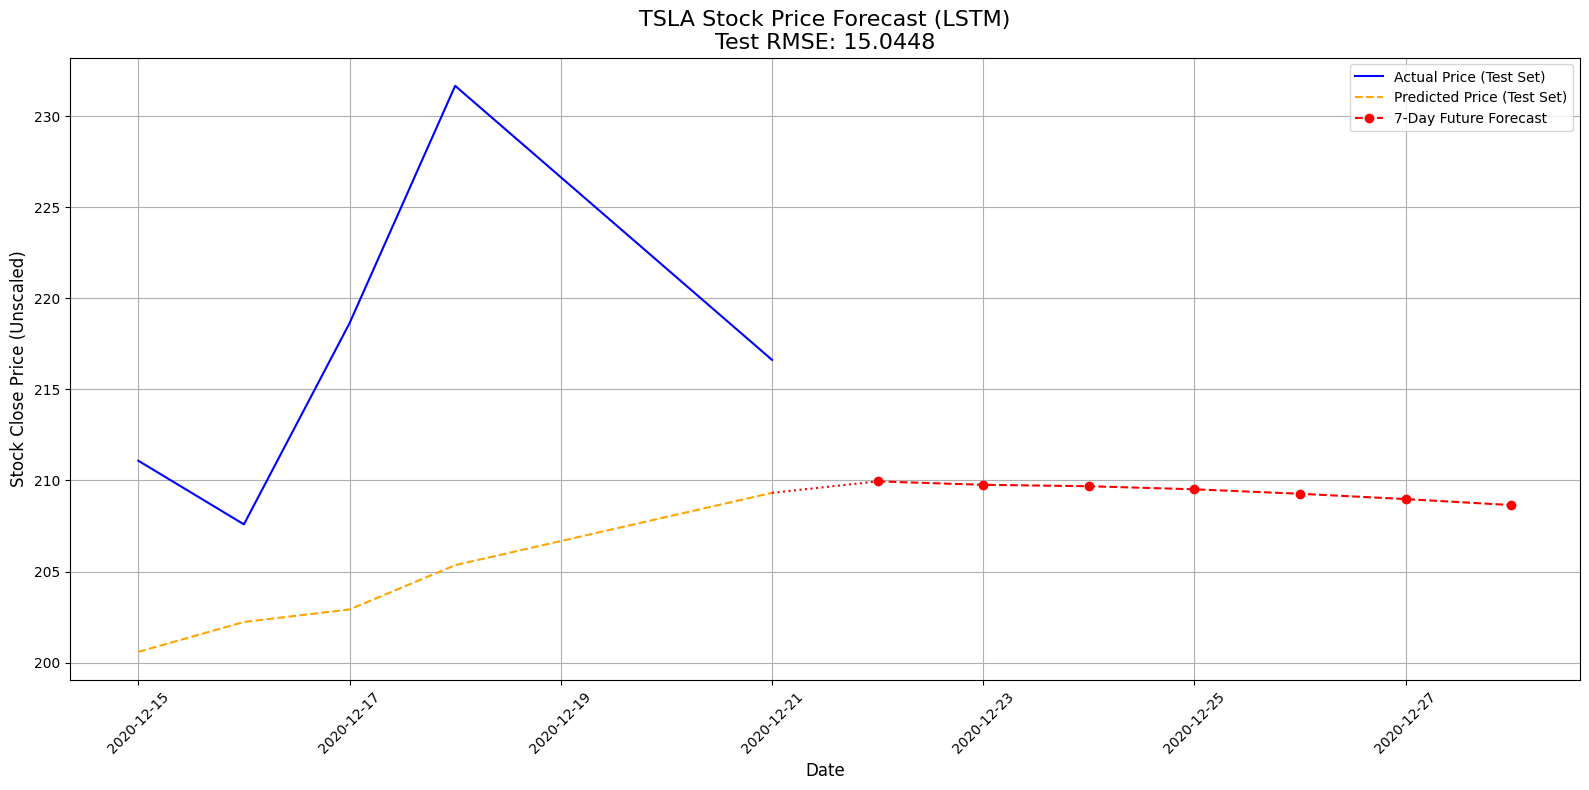

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql.functions import col
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from typing import Tuple, List

TARGET_TEST_TABLE = "project_model.test_data"
TICKERS_TO_ANALYZE = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX'] 
TIME_STEPS = 30  #  defined look-back window
TARGET_COLUMN = 'closing_price'
FEATURE_COLUMNS = ['closing_price', 'daily_avg_sentiment'] 

def create_sequences(data: np.ndarray, time_steps: int) -> Tuple[np.ndarray, np.ndarray]:
    """Transforms time-series data into sequences (X) and next-step targets (y)."""
    Xs, ys = [], []
   
    for i in range(len(data) - time_steps):
        X = data[i:(i + time_steps)]  
        y = data[i + time_steps, 0]   
        Xs.append(X)
        ys.append(y)
    return np.array(Xs), np.array(ys)

def forecast_multi_step(ticker, model, feature_scaler, price_scaler, test_data_pd, forecast_horizon):
    """
    Generates a recursive multi-step forecast using the last sequence of the test set.
    """
    # 1. Prepare the starting input sequence 
    ticker_test_data = test_data_pd[test_data_pd['ticker'] == ticker].sort_values('trade_date')
    
    if len(ticker_test_data) < TIME_STEPS:
        return []

    # Get the last TIME_STEPS rows 
    last_window_features = ticker_test_data[FEATURE_COLUMNS].tail(TIME_STEPS).values
    
    X_input_scaled = feature_scaler.transform(last_window_features)
    # Reshape for LSTM
    X_input = X_input_scaled.reshape(1, TIME_STEPS, len(FEATURE_COLUMNS))
    
    target_index = FEATURE_COLUMNS.index(TARGET_COLUMN)
    future_predictions = []
    
    for i in range(forecast_horizon):
        # 2. Predict the next time step (t+1)
        y_pred_scaled = model.predict(X_input, verbose=0)
        
        # 3. Inverse-transform the predicted target price for reporting
        y_pred_unscaled_price = price_scaler.inverse_transform(y_pred_scaled)[0, 0]
        future_predictions.append(y_pred_unscaled_price)
        
        # 4. Prepare the input for the next prediction (t+2)
        new_step_features_scaled = X_input[0, -1, :].copy()
        new_step_features_scaled[target_index] = y_pred_scaled[0, 0]
        
        new_X_input = np.concatenate(
            (X_input[:, 1:, :], new_step_features_scaled.reshape(1, 1, -1)),
            axis=1
        )
        X_input = new_X_input

    return future_predictions


# 1. DATA LOADING

print("Loading test data from Spark...")
df_spark_test = spark.table(TARGET_TEST_TABLE)
test_data_pd = df_spark_test.toPandas()
print("Test data loaded successfully into test_data_pd.")

lstm_test_results = {}
plot_data = {}
forecast_results = {}
FORECAST_DAYS = 7
FORECAST_STEPS = [1, 3, 7]

# 2. LOOP FOR SINGLE-STEP EVALUATION (RMSE, MAE, MAPE, R²) AND MULTI-STEP FORECASTING

print("\n--- Starting LSTM Evaluation and Forecasting ---")

for ticker in TICKERS_TO_ANALYZE:
    print(f"\n--- Processing {ticker} ---")
    
    if ticker not in fitted_lstm_objects:
        print(f"Skipping {ticker}: Model not found. Did the training step complete?")
        continue
        
    model_data = fitted_lstm_objects[ticker]
    model = model_data['model']
    feature_scaler = model_data['feature_scaler']
    price_scaler = model_data['price_scaler']
    
    ticker_test_data = test_data_pd[test_data_pd['ticker'] == ticker].sort_values('trade_date')
    df_data = ticker_test_data[FEATURE_COLUMNS]
    
    if len(df_data) <= TIME_STEPS:
        print(f"Skipping {ticker}: Not enough test data (need > {TIME_STEPS} days).")
        continue

    data_scaled = feature_scaler.transform(df_data)
    
    X_test_sequence, y_test_target_scaled = create_sequences(data_scaled, TIME_STEPS)

    # 2a. Single-Step Prediction and Metrics Calculation 
    y_pred_scaled = model.predict(X_test_sequence, verbose=0)

    y_pred_unscaled = price_scaler.inverse_transform(y_pred_scaled).flatten()
    y_test_true = price_scaler.inverse_transform(y_test_target_scaled.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_unscaled))
    mae = mean_absolute_error(y_test_true, y_pred_unscaled)
    mape = np.mean(np.abs((y_test_true - y_pred_unscaled) / y_test_true)) * 100  # %
    r2 = r2_score(y_test_true, y_pred_unscaled)

    lstm_test_results[ticker] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'R2': r2
    }

    print("Single-step test metrics:")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MAE  = {mae:.4f}")
    print(f"  MAPE = {mape:.2f}%")
    print(f"  R²   = {r2:.4f}")

    plot_data[ticker] = {
        'dates': ticker_test_data['trade_date'].iloc[TIME_STEPS:].values,
        'y_true': y_test_true,
        'y_pred': y_pred_unscaled
    }

    #2b. Multi-Step Future Forecast (1, 3, 7 days) 
    full_forecast_series = forecast_multi_step(
        ticker, model, feature_scaler, price_scaler, test_data_pd, FORECAST_DAYS
    )

    if full_forecast_series:
        forecast_results[ticker] = {
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R2': r2,
            '1_day_forecast': full_forecast_series[0],
            '3_day_forecast': full_forecast_series[2],
            '7_day_forecast': full_forecast_series[6],
            'full_forecast_series': full_forecast_series  # Storing full array for plotting
        }
        print(f"  +1 Day Future Forecast: ${full_forecast_series[0]:.2f}")
    else:
        print("  Could not generate multi-step forecast (insufficient data).")


# 3. FINAL SUMMARY AND VISUALIZATION

# Final Summary Table 
print("LSTM Model Evaluation & Forecast Summary")
print(f"{'Ticker':<8} | {'RMSE':<10} | {'MAE':<10} | {'MAPE%':<8} | {'R2':<8} | "
      f"{'+1 Day Price':<12} | {'+3 Day Price':<12} | {'+7 Day Price':<12}")
print("-" * 100)
for ticker, results in forecast_results.items():
    print(
        f"{ticker:<8} | "
        f"{results['RMSE']:.4f}{'':<2} | "
        f"{results['MAE']:.4f}{'':<2} | "
        f"{results['MAPE']:.2f}{'':<2} | "
        f"{results.get('R2', float('nan')):.4f} | "
        f"${results['1_day_forecast']:.2f}{'':<10} | "
        f"${results['3_day_forecast']:.2f}{'':<10} | "
        f"${results['7_day_forecast']:.2f}"
    )

#  Visualization for the first ticker in the list 
if plot_data and forecast_results:
    TICKER_FOR_PLOT = TICKERS_TO_ANALYZE[0]
    
    if TICKER_FOR_PLOT in plot_data and TICKER_FOR_PLOT in forecast_results:
        data = plot_data[TICKER_FOR_PLOT]
        dates = data['dates']
        
        full_forecast_7_day = forecast_results[TICKER_FOR_PLOT]['full_forecast_series']

        # Prepare forecast dates
        last_test_date = dates[-1]
        forecast_dates = pd.date_range(last_test_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

        plt.figure(figsize=(16, 8))
        
        plt.plot(dates, data['y_true'], label='Actual Price (Test Set)', color='blue')
        plt.plot(dates, data['y_pred'], label='Predicted Price (Test Set)', color='orange', linestyle='--')
        
        plt.plot(forecast_dates, full_forecast_7_day, label='7-Day Future Forecast', color='red', marker='o', linestyle='--')

        plt.plot([dates[-1], forecast_dates[0]],
                 [data['y_pred'][-1], full_forecast_7_day[0]],
                 color='red', linestyle=':', marker='')
        
        rmse_value = forecast_results[TICKER_FOR_PLOT]['RMSE']
        plt.title(f'{TICKER_FOR_PLOT} Stock Price Forecast (LSTM)\nTest RMSE: {rmse_value:.4f}', fontsize=16)

        plt.xlabel('Date', fontsize=12)
        plt.ylabel('Stock Close Price (Unscaled)', fontsize=12)
        plt.legend(fontsize=10)
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [ ]:


import pandas as pd

lstm_results_list = []

for ticker, res in forecast_results.items():
    lstm_results_list.append({
        "ticker": ticker,
        "rmse": float(res["RMSE"]),                 
        "mae": float(res["MAE"]),
        "mape": float(res["MAPE"]),
        "r2": float(res.get("R2", float("nan"))),
        "forecast_1d": float(res["1_day_forecast"]),
        "forecast_3d": float(res["3_day_forecast"]),
        "forecast_7d": float(res["7_day_forecast"]),
    })

lstm_results_df = pd.DataFrame(lstm_results_list)

expected_cols = [
    "ticker",
    "rmse",
    "mae",
    "mape",
    "r2",
    "forecast_1d",
    "forecast_3d",
    "forecast_7d",
]
lstm_results_df = lstm_results_df[expected_cols]

display(lstm_results_df)

lstm_results_sdf = spark.createDataFrame(lstm_results_df)

(
    lstm_results_sdf
        .write
        .mode("overwrite")
        .option("mergeSchema", "true")
        .saveAsTable("project_model.lstm_summary")
)

print("Saved LSTM summary to table: project_model.lstm_summary")

ticker,rmse,mae,mape,r2,forecast_1d,forecast_3d,forecast_7d
TSLA,15.04482091365055,13.037371826171869,5.894306467504534,-2.3148974567974827,209.9493865966797,209.6827392578125,208.6492156982422
MSFT,6.932964666515741,6.570803833007818,2.991299882047599,-5.5250670431280495,214.71261596679688,214.37313842773438,212.248046875
AAPL,5.666928566536812,5.539897155761719,4.329645892440088,-69.26219187711696,123.8157958984375,123.1971435546875,121.8759994506836
AMZN,3.0897741506281626,2.730902099609375,1.6940140804662922,-4.108977588249123,158.1956024169922,157.91680908203125,157.30697631835938
NFLX,25.751946489903215,25.446795654296874,4.815049507933631,-22.041483940663344,511.9141540527344,509.645751953125,506.20562744140625


Saved LSTM summary to table: project_model.lstm_summary


---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import functions as F

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

In [ ]:
# Load the SARIMAX and LSTM summaries  saved earlier
sarimax_sdf = spark.table("project_model.sarimax_summary")
lstm_sdf    = spark.table("project_model.lstm_summary")

sarimax_pdf = sarimax_sdf.toPandas()
lstm_pdf    = lstm_sdf.toPandas()

print("SARIMAX summary:")
display(sarimax_pdf)

print("LSTM summary:")
display(lstm_pdf)

SARIMAX summary:


ticker,rmse,forecast_1d,forecast_3d,forecast_7d,mae,mape,r2
TSLA,57.93991934137636,129.16790829640996,129.34666442871094,129.34666442871094,48.74519047457188,24.98341840831733,-2.41079791647708
MSFT,12.440979219729835,202.90365475285776,203.12145671188918,203.0886102974634,11.759478930387013,5.439900786360306,-7.540551748710756
AAPL,11.198487864102145,110.40550394129205,110.0004953629781,109.92061433020345,10.23873167790999,8.38872777871055,-4.652895981403665
AMZN,6.152701115656931,153.34865965334697,153.32185575313085,152.21399024873963,5.318577372143522,3.3319191656199934,-2.3041833509308502
NFLX,81.28574308701619,508.17090203353814,510.34301004173,514.7151188914563,53.87631295562762,10.901676897755353,-21.208523928645743


LSTM summary:


ticker,rmse,forecast_1d,forecast_3d,forecast_7d,mae,mape,r2
TSLA,15.04482091365055,209.9493865966797,209.6827392578125,208.6492156982422,13.037371826171869,5.894306467504534,-2.3148974567974827
MSFT,6.932964666515741,214.71261596679688,214.37313842773438,212.248046875,6.570803833007818,2.991299882047599,-5.5250670431280495
AAPL,5.666928566536812,123.8157958984375,123.1971435546875,121.8759994506836,5.539897155761719,4.329645892440088,-69.26219187711696
AMZN,3.0897741506281626,158.1956024169922,157.91680908203125,157.30697631835938,2.730902099609375,1.6940140804662922,-4.108977588249123
NFLX,25.751946489903215,511.9141540527344,509.645751953125,506.20562744140625,25.446795654296874,4.815049507933631,-22.041483940663344


In [ ]:
# Extract metrics from SARIMAX summary
sarimax_metrics = sarimax_pdf[["ticker", "rmse", "mae", "mape", "r2"]].rename(columns={
    "rmse": "sarimax_rmse",
    "mae": "sarimax_mae",
    "mape": "sarimax_mape",
    "r2": "sarimax_r2"
})

# Extract metrics from LSTM summary
lstm_metrics = lstm_pdf[["ticker", "rmse", "mae", "mape", "r2"]].rename(columns={
    "rmse": "lstm_rmse",
    "mae": "lstm_mae",
    "mape": "lstm_mape",
    "r2": "lstm_r2"
})

comparison_df = pd.merge(sarimax_metrics, lstm_metrics, on="ticker", how="inner")

comparison_df["better_model_rmse"] = np.where(
    comparison_df["lstm_rmse"] < comparison_df["sarimax_rmse"],
    "LSTM",
    "SARIMAX"
)

comparison_df["better_model_mae"] = np.where(
    comparison_df["lstm_mae"] < comparison_df["sarimax_mae"],
    "LSTM",
    "SARIMAX"
)

comparison_df["better_model_mape"] = np.where(
    comparison_df["lstm_mape"] < comparison_df["sarimax_mape"],
    "LSTM",
    "SARIMAX"
)

print("Combined metric comparison (RMSE, MAE, MAPE, R²):")
display(comparison_df)

Combined metric comparison (RMSE, MAE, MAPE, R²):


ticker,sarimax_rmse,sarimax_mae,sarimax_mape,sarimax_r2,lstm_rmse,lstm_mae,lstm_mape,lstm_r2,better_model_rmse,better_model_mae,better_model_mape
TSLA,57.93991934137636,48.74519047457188,24.98341840831733,-2.41079791647708,15.04482091365055,13.037371826171869,5.894306467504534,-2.3148974567974827,LSTM,LSTM,LSTM
MSFT,12.440979219729835,11.759478930387013,5.439900786360306,-7.540551748710756,6.932964666515741,6.570803833007818,2.991299882047599,-5.5250670431280495,LSTM,LSTM,LSTM
AAPL,11.198487864102145,10.23873167790999,8.38872777871055,-4.652895981403665,5.666928566536812,5.539897155761719,4.329645892440088,-69.26219187711696,LSTM,LSTM,LSTM
AMZN,6.152701115656931,5.318577372143522,3.3319191656199934,-2.3041833509308502,3.0897741506281626,2.730902099609375,1.6940140804662922,-4.108977588249123,LSTM,LSTM,LSTM
NFLX,81.28574308701619,53.87631295562762,10.901676897755353,-21.208523928645743,25.751946489903215,25.446795654296874,4.815049507933631,-22.041483940663344,LSTM,LSTM,LSTM


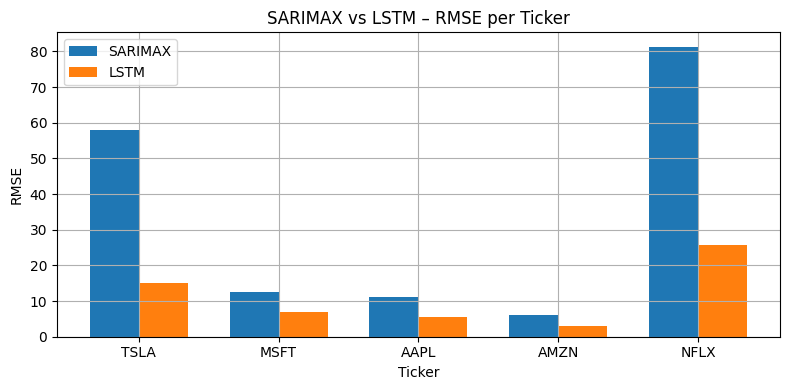

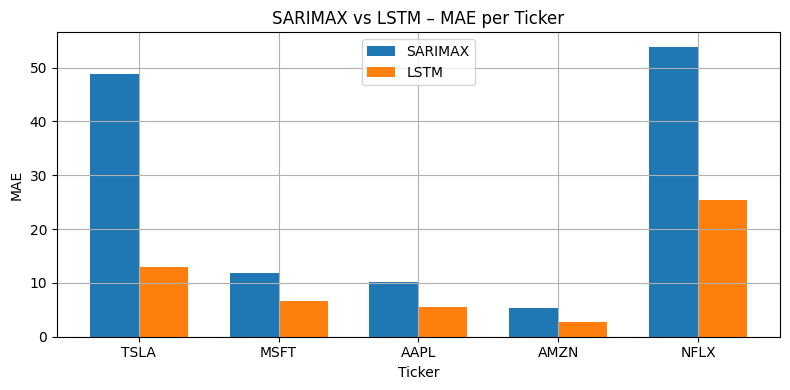

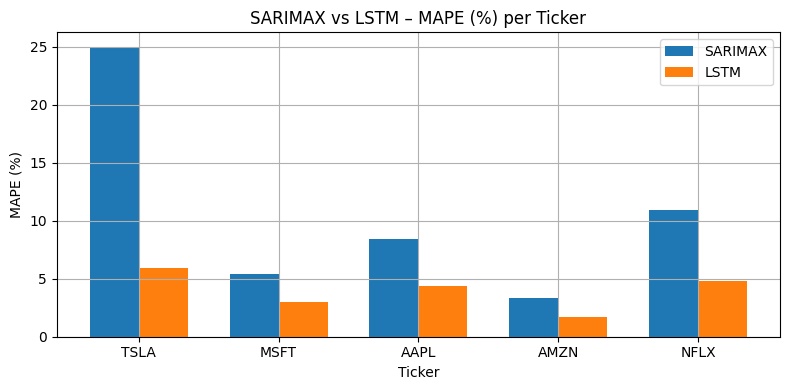

In [ ]:
metrics_to_plot = ["rmse", "mae", "mape"]

tickers = comparison_df["ticker"].values
x = np.arange(len(tickers))  

for metric in metrics_to_plot:
    sarimax_col = f"sarimax_{metric}"
    lstm_col    = f"lstm_{metric}"

    sarimax_vals = comparison_df[sarimax_col].values
    lstm_vals    = comparison_df[lstm_col].values

    width = 0.35  # bar width

    plt.figure(figsize=(8, 4))
    plt.bar(x - width/2, sarimax_vals, width, label="SARIMAX")
    plt.bar(x + width/2, lstm_vals,    width, label="LSTM")

    title_metric = metric.upper() if metric != "mape" else "MAPE (%)"
    plt.title(f"SARIMAX vs LSTM – {title_metric} per Ticker")
    plt.xlabel("Ticker")
    if metric == "mape":
        plt.ylabel("MAPE (%)")
    else:
        plt.ylabel(metric.upper())

    plt.xticks(x, tickers)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
from pyspark.sql import functions as F

# Load the final features table
features_sdf = spark.table("project_clean.final_features")

print("Schema of final_features:")
features_sdf.printSchema()

print("\nDistinct tickers in the dataset:")
features_sdf.select("ticker").distinct().show()

Schema of final_features:
root
 |-- trade_date: date (nullable = true)
 |-- ticker: string (nullable = true)
 |-- closing_price: double (nullable = true)
 |-- daily_avg_sentiment: double (nullable = true)
 |-- lag_1_day_close: double (nullable = true)
 |-- lag_3_day_close: double (nullable = true)
 |-- lag_7_day_close: double (nullable = true)
 |-- ma_5_day_close: double (nullable = true)
 |-- ma_20_day_close: double (nullable = true)
 |-- target_1_day: double (nullable = true)
 |-- target_3_day: double (nullable = true)
 |-- target_7_day: double (nullable = true)


Distinct tickers in the dataset:
+-------+
| ticker|
+-------+
|  BRK-B|
|   AAPL|
|    CCL|
|    JPM|
|   META|
|    DIS|
|   TSLA|
|     PG|
|    MCD|
|    AMT|
|    PFE|
|   GOOG|
|     FB|
|   NFLX|
|    JNJ|
|    CVX|
|   ABNB|
|%5EGSPC|
|  GOOGL|
|    LOW|
+-------+
only showing top 20 rows


In [ ]:
features_sdf.select("closing_price", "daily_avg_sentiment").describe().show()

+-------+-----------------+--------------------+
|summary|    closing_price| daily_avg_sentiment|
+-------+-----------------+--------------------+
|  count|             9888|                9888|
|   mean|7924.761351334576|0.015739874956163677|
| stddev|48063.61570831263| 0.11020210341410887|
|    min| 7.96999979019165|              -0.969|
|    max|         351101.0|              0.9732|
+-------+-----------------+--------------------+



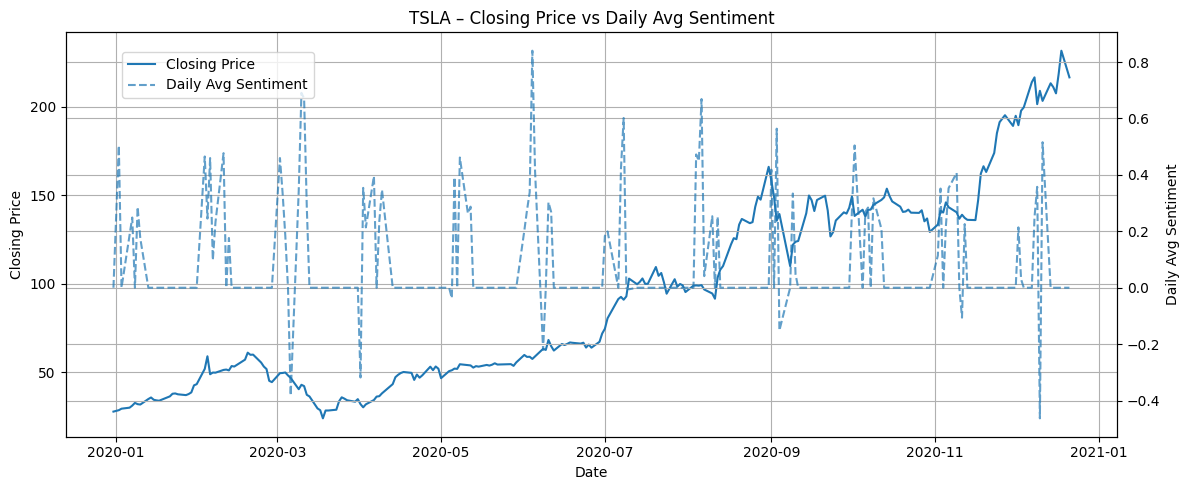

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

TICKER_FOR_EDA = "TSLA"   # e.g. TSLA, MSFT, AAPL, AMZN, NFLX

ticker_pdf = (
    features_sdf
    .filter(F.col("ticker") == TICKER_FOR_EDA)
    .orderBy("trade_date")
    .toPandas()
)

if ticker_pdf.empty:
    print(f"No data found for ticker {TICKER_FOR_EDA}")
else:
    ticker_pdf["trade_date"] = pd.to_datetime(ticker_pdf["trade_date"])

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(ticker_pdf["trade_date"], ticker_pdf["closing_price"], label="Closing Price", linewidth=1.5)
    ax1.set_xlabel("Date")
    ax1.set_ylabel("Closing Price")
    
    ax2 = ax1.twinx()
    ax2.plot(ticker_pdf["trade_date"], ticker_pdf["daily_avg_sentiment"], 
             label="Daily Avg Sentiment", linestyle="--", alpha=0.7)
    ax2.set_ylabel("Daily Avg Sentiment")

    plt.title(f"{TICKER_FOR_EDA} – Closing Price vs Daily Avg Sentiment")
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()

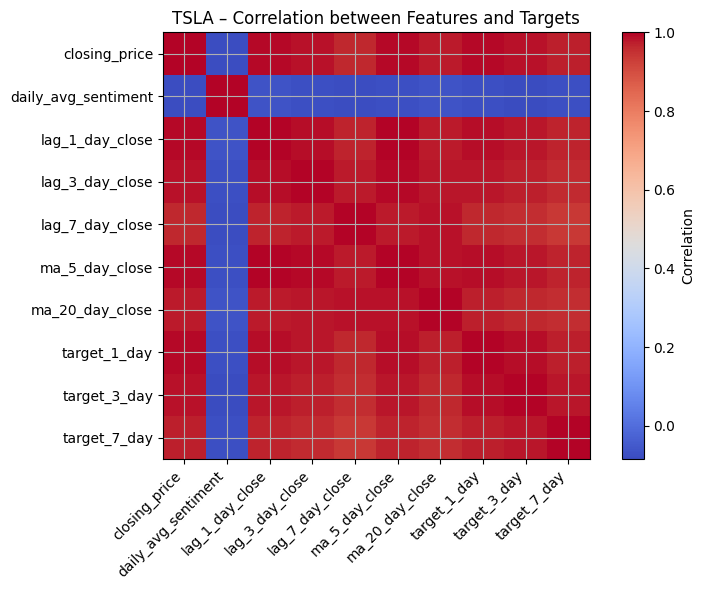

In [ ]:
desired_cols = [
    "closing_price",
    "daily_avg_sentiment",
    "lag_1_day_close",
    "lag_3_day_close",
    "lag_7_day_close",
    "ma_5_day_close",
    "ma_20_day_close",
    "target_1_day",
    "target_3_day",
    "target_7_day",
]

if ticker_pdf.empty:
    print(f"Cannot compute correlations: no data for {TICKER_FOR_EDA}")
else:
    available_cols = [c for c in desired_cols if c in ticker_pdf.columns]

    if len(available_cols) < 2:
        print(f"Not enough numeric columns available for correlation (found: {available_cols})")
    else:
        corr_matrix = ticker_pdf[available_cols].corr()

        plt.figure(figsize=(8, 6))
        plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
        plt.colorbar(label="Correlation")

        plt.xticks(range(len(available_cols)), available_cols, rotation=45, ha="right")
        plt.yticks(range(len(available_cols)), available_cols)

        plt.title(f"{TICKER_FOR_EDA} – Correlation between Features and Targets")
        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from pyspark.sql import functions as F

TICKER_FOR_TUNING = "TSLA"  

train_sdf = spark.table("project_model.train_data")

train_pdf = (
    train_sdf
    .filter(F.col("ticker") == TICKER_FOR_TUNING)
    .orderBy("trade_date")
    .toPandas()
)

if train_pdf.empty:
    raise ValueError(f"No training data found for ticker {TICKER_FOR_TUNING}")

train_pdf["trade_date"] = pd.to_datetime(train_pdf["trade_date"])


feature_cols = ["closing_price", "daily_avg_sentiment"]
features = train_pdf[feature_cols].values.astype(np.float32)

feature_scaler = MinMaxScaler()
features_scaled = feature_scaler.fit_transform(features)

price_scaler = MinMaxScaler()
prices_scaled = price_scaler.fit_transform(train_pdf[["closing_price"]].values.astype(np.float32))

In [ ]:
def create_sequences_for_tuning(data_scaled, target_scaled, time_steps):
    X, y = [], []
    for i in range(time_steps, len(data_scaled)):
        X.append(data_scaled[i - time_steps:i, :])
        y.append(target_scaled[i, 0]) 
    return np.array(X), np.array(y)

In [ ]:
tuning_configs = [
    {"name": "baseline",      "time_steps": 30, "units": 50, "dropout": 0.2},
    {"name": "short_window",  "time_steps": 20, "units": 50, "dropout": 0.2},
    {"name": "more_units",    "time_steps": 30, "units": 64, "dropout": 0.3},
]

def build_lstm_model(units, dropout, input_shape):
    model = Sequential()
    model.add(LSTM(units, activation="relu", input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer="adam", loss="mse")
    return model

In [ ]:
tuning_results = []

for cfg in tuning_configs:
    ts = cfg["time_steps"]
    print(f"\n=== Config: {cfg['name']} (time_steps={ts}, units={cfg['units']}, dropout={cfg['dropout']}) ===")

    X_all, y_all = create_sequences_for_tuning(features_scaled, prices_scaled, time_steps=ts)

    if len(X_all) < 10:
        print("Not enough data for this configuration, skipping.")
        continue

    split_idx = int(len(X_all) * 0.8)
    X_train, X_val = X_all[:split_idx], X_all[split_idx:]
    y_train, y_val = y_all[:split_idx], y_all[split_idx:]

    model = build_lstm_model(
        units=cfg["units"],
        dropout=cfg["dropout"],
        input_shape=(X_train.shape[1], X_train.shape[2])
    )

    es = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=0
    )

    best_val_loss = min(history.history["val_loss"])
    best_val_rmse = float(np.sqrt(best_val_loss))

    print(f"Best validation RMSE (scaled): {best_val_rmse:.4f}")

    tuning_results.append({
        "config_name": cfg["name"],
        "time_steps": ts,
        "units": cfg["units"],
        "dropout": cfg["dropout"],
        "val_rmse_scaled": best_val_rmse,
    })

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df.sort_values("val_rmse_scaled")


=== Config: baseline (time_steps=30, units=50, dropout=0.2) ===
Best validation RMSE (scaled): 0.0615

=== Config: short_window (time_steps=20, units=50, dropout=0.2) ===
Best validation RMSE (scaled): 0.0592

=== Config: more_units (time_steps=30, units=64, dropout=0.3) ===
Best validation RMSE (scaled): 0.0553


,config_name,time_steps,units,dropout,val_rmse_scaled
2,more_units,30,64,0.3,0.055338
1,short_window,20,50,0.2,0.059181
0,baseline,30,50,0.2,0.061451


In [ ]:
import pandas as pd

# Load summaries saved from the modelling notebook
sarimax_sdf = spark.table("project_model.sarimax_summary")
lstm_sdf    = spark.table("project_model.lstm_summary")

sarimax_pdf = sarimax_sdf.toPandas()
lstm_pdf    = lstm_sdf.toPandas()

print("SARIMAX summary:")
display(sarimax_pdf)

print("LSTM summary:")
display(lstm_pdf)

SARIMAX summary:


ticker,rmse,forecast_1d,forecast_3d,forecast_7d,mae,mape,r2
TSLA,57.93991934137636,129.16790829640996,129.34666442871094,129.34666442871094,48.74519047457188,24.98341840831733,-2.41079791647708
MSFT,12.440979219729835,202.90365475285776,203.12145671188918,203.0886102974634,11.759478930387013,5.439900786360306,-7.540551748710756
AAPL,11.198487864102145,110.40550394129205,110.0004953629781,109.92061433020345,10.23873167790999,8.38872777871055,-4.652895981403665
AMZN,6.152701115656931,153.34865965334697,153.32185575313085,152.21399024873963,5.318577372143522,3.3319191656199934,-2.3041833509308502
NFLX,81.28574308701619,508.17090203353814,510.34301004173,514.7151188914563,53.87631295562762,10.901676897755353,-21.208523928645743


LSTM summary:


ticker,rmse,forecast_1d,forecast_3d,forecast_7d,mae,mape,r2
TSLA,15.04482091365055,209.9493865966797,209.6827392578125,208.6492156982422,13.037371826171869,5.894306467504534,-2.3148974567974827
MSFT,6.932964666515741,214.71261596679688,214.37313842773438,212.248046875,6.570803833007818,2.991299882047599,-5.5250670431280495
AAPL,5.666928566536812,123.8157958984375,123.1971435546875,121.8759994506836,5.539897155761719,4.329645892440088,-69.26219187711696
AMZN,3.0897741506281626,158.1956024169922,157.91680908203125,157.30697631835938,2.730902099609375,1.6940140804662922,-4.108977588249123
NFLX,25.751946489903215,511.9141540527344,509.645751953125,506.20562744140625,25.446795654296874,4.815049507933631,-22.041483940663344


In [ ]:
# Create aligned DataFrames with a model_type column

sarimax_export = sarimax_pdf.copy()
sarimax_export["model_type"] = "SARIMAX"

lstm_export = lstm_pdf.copy()
lstm_export["model_type"] = "LSTM"

cols_needed = ["ticker", "model_type", "rmse", "forecast_1d", "forecast_3d", "forecast_7d"]

sarimax_export = sarimax_export[[c for c in cols_needed if c in sarimax_export.columns]]
lstm_export    = lstm_export[[c for c in cols_needed if c in lstm_export.columns]]

forecast_export_df = pd.concat([sarimax_export, lstm_export], ignore_index=True)

print("Combined forecast summary for dashboard:")
display(forecast_export_df)

Combined forecast summary for dashboard:


ticker,model_type,rmse,forecast_1d,forecast_3d,forecast_7d
TSLA,SARIMAX,57.93991934137636,129.16790829640996,129.34666442871094,129.34666442871094
MSFT,SARIMAX,12.440979219729835,202.90365475285776,203.12145671188918,203.0886102974634
AAPL,SARIMAX,11.198487864102145,110.40550394129205,110.0004953629781,109.92061433020345
AMZN,SARIMAX,6.152701115656931,153.34865965334697,153.32185575313085,152.21399024873963
NFLX,SARIMAX,81.28574308701619,508.17090203353814,510.34301004173,514.7151188914563
TSLA,LSTM,15.04482091365055,209.9493865966797,209.6827392578125,208.6492156982422
MSFT,LSTM,6.932964666515741,214.71261596679688,214.37313842773438,212.248046875
AAPL,LSTM,5.666928566536812,123.8157958984375,123.1971435546875,121.8759994506836
AMZN,LSTM,3.0897741506281626,158.1956024169922,157.91680908203125,157.30697631835938
NFLX,LSTM,25.751946489903215,511.9141540527344,509.645751953125,506.20562744140625


In [ ]:
forecast_export_sdf = spark.createDataFrame(forecast_export_df)

(
    forecast_export_sdf
        .write
        .mode("overwrite")
        .saveAsTable("project_model.forecast_summary_for_dashboard")
)

print("Saved dashboard-ready table: project_model.forecast_summary_for_dashboard")

Saved dashboard-ready table: project_model.forecast_summary_for_dashboard


---

In [ ]:
import pandas as pd
import plotly.graph_objects as go
from pyspark.sql import functions as F
import plotly.io as pio

# Make sure Plotly uses the right renderer in Databricks
pio.renderers.default = "databricks"  # or "notebook" if 're in classic Jupyter


# 1. Load history & forecast summary from Spark, convert to Pandas

features_sdf = spark.table("project_clean.final_features")
forecast_sdf = spark.table("project_model.forecast_summary_for_dashboard")

features_pdf = features_sdf.toPandas()
forecast_pdf = forecast_sdf.toPandas()

features_pdf["trade_date"] = pd.to_datetime(features_pdf["trade_date"])

TRAINED_TICKERS = ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX']
available_forecast_tickers = sorted(forecast_pdf["ticker"].unique())
tickers = [t for t in TRAINED_TICKERS if t in available_forecast_tickers]

models = sorted(forecast_pdf["model_type"].unique())
print("Tickers:", tickers)
print("Models: ", models)
fig = go.Figure()
ticker_trace_indices = {}
num_traces = 0

for ticker in tickers:
    hist = (
        features_pdf[features_pdf["ticker"] == ticker]
        .sort_values("trade_date")
        .copy()
    )
    if hist.empty:
        continue

    last_date = hist["trade_date"].max()

    fcast = forecast_pdf[forecast_pdf["ticker"] == ticker].copy()
    if fcast.empty:
        continue

    ticker_trace_indices[ticker] = []

    idx_hist = num_traces
    fig.add_trace(go.Scatter(
        x=hist["trade_date"],
        y=hist["closing_price"],
        mode="lines",
        name=f"{ticker} Historical Close",
    ))
    ticker_trace_indices[ticker].append(idx_hist)
    num_traces += 1

    for _, row in fcast.iterrows():
        model = row["model_type"]
        f1 = row.get("forecast_1d", None)
        f3 = row.get("forecast_3d", None)
        f7 = row.get("forecast_7d", None)

        if f1 is None or f3 is None or f7 is None:
            continue

        future_dates = [
            last_date + pd.Timedelta(days=1),
            last_date + pd.Timedelta(days=3),
            last_date + pd.Timedelta(days=7),
        ]
        future_values = [f1, f3, f7]

        idx_model = num_traces
        fig.add_trace(go.Scatter(
            x=future_dates,
            y=future_values,
            mode="markers+lines",
            name=f"{ticker} {model} Forecast (1/3/7 days)",
        ))
        ticker_trace_indices[ticker].append(idx_model)
        num_traces += 1


# 3. Create dropdown buttons to toggle visibility by ticker

buttons = []
total_traces = len(fig.data)

for i, ticker in enumerate(tickers):
    vis = [False] * total_traces
    for idx in ticker_trace_indices.get(ticker, []):
        vis[idx] = True

    buttons.append(dict(
        label=ticker,
        method="update",
        args=[
            {"visible": vis},
            {"title": f"{ticker} – Historical Close & 1/3/7-Day Forecasts"}
        ],
    ))

if tickers:
    initial_vis = [False] * total_traces
    for idx in ticker_trace_indices[tickers[0]]:
        initial_vis[idx] = True
    for j, v in enumerate(initial_vis):
        fig.data[j].visible = v

fig.update_layout(
    title=f"{tickers[0]} – Historical Close & 1/3/7-Day Forecasts" if tickers else "No data",
    xaxis_title="Date",
    yaxis_title="Closing Price",
    hovermode="x unified",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.01,
            y=1.15,
            xanchor="left",
            yanchor="top",
        )
    ],
)

fig.show()

Tickers: ['TSLA', 'MSFT', 'AAPL', 'AMZN', 'NFLX']
Models:  ['LSTM', 'SARIMAX']


---

In [ ]:
stream_input_path = "/FileStore/user_input_stream/input"

dbutils.fs.mkdirs(stream_input_path)
dbutils.fs.ls("/FileStore/user_input_stream")

[FileInfo(path='dbfs:/FileStore/user_input_stream/input/', name='input/', size=0, modificationTime=1765023146000)]

In [ ]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, TimestampType
from pyspark.sql.functions import col, window, avg

stream_input_path = "/FileStore/user_input_stream/input"

schema = StructType([
    StructField("event_time", StringType(), True),
    StructField("ticker", StringType(), True),
    StructField("price", DoubleType(), True),
    StructField("sentiment", DoubleType(), True),
])

streaming_df = (spark.readStream
    .schema(schema)
    .option("header", "true")
    .csv(stream_input_path)
)

streaming_df_ts = streaming_df.withColumn(
    "event_time_ts",
    col("event_time").cast(TimestampType())
)

agg_df = (streaming_df_ts
    .groupBy(
        window(col("event_time_ts"), "1 minute"),
        col("ticker")
    )
    .agg(
        avg("price").alias("avg_price"),
        avg("sentiment").alias("avg_sentiment")
    )
    .orderBy("window")
)

# In Databricks this starts the stream and shows a live updating table
display(agg_df)

window,ticker,avg_price,avg_sentiment
"List(2025-12-06T12:13:00Z, 2025-12-06T12:14:00Z)",TSLA,216.125,-0.015
"List(2025-12-06T12:13:00Z, 2025-12-06T12:14:00Z)",AAPL,287.75,0.022499999999999992
"List(2025-12-06T12:13:00Z, 2025-12-06T12:14:00Z)",MSFT,272.1975,-0.2725
"List(2025-12-06T12:14:00Z, 2025-12-06T12:15:00Z)",TSLA,252.8,0.04
"List(2025-12-06T12:14:00Z, 2025-12-06T12:15:00Z)",AAPL,224.16,-0.69
"List(2025-12-06T12:14:00Z, 2025-12-06T12:15:00Z)",MSFT,372.74,0.06
"List(2025-12-09T05:05:00Z, 2025-12-09T05:06:00Z)",TSLA,212.335,0.695
"List(2025-12-09T05:05:00Z, 2025-12-09T05:06:00Z)",MSFT,310.845,-0.8
"List(2025-12-09T05:05:00Z, 2025-12-09T05:06:00Z)",AAPL,289.135,-0.45999999999999996
"List(2025-12-09T05:06:00Z, 2025-12-09T05:07:00Z)",AAPL,271.21799999999996,-0.17600000000000002


In [ ]:
import time
from datetime import datetime
import random
import pandas as pd

stream_input_path = "/FileStore/user_input_stream/input"

tickers = ["AAPL", "MSFT", "TSLA"]

def create_user_events_once():
    now = datetime.now().isoformat(timespec="seconds")
    rows = []

    for t in tickers:
       
        price = round(random.uniform(100, 400), 2)
        sentiment = round(random.uniform(-1, 1), 2)  # -1 = very negative, +1 = very positive
        rows.append((now, t, price, sentiment))

    pdf = pd.DataFrame(rows, columns=["event_time", "ticker", "price", "sentiment"])
    df = spark.createDataFrame(pdf)

    (df.write
       .mode("append")
       .option("header", "true")
       .csv(stream_input_path))

    return pdf

for i in range(5):
    batch_pdf = create_user_events_once()
    print(f"User batch {i+1} written:")
    display(batch_pdf)
    time.sleep(5)

User batch 1 written:


event_time,ticker,price,sentiment
2025-12-10T13:05:20,AAPL,195.98,-0.8
2025-12-10T13:05:20,MSFT,334.55,0.12
2025-12-10T13:05:20,TSLA,292.66,0.46


User batch 2 written:


event_time,ticker,price,sentiment
2025-12-10T13:05:26,AAPL,135.67,-0.95
2025-12-10T13:05:26,MSFT,189.96,-0.35
2025-12-10T13:05:26,TSLA,300.13,-0.77


User batch 3 written:


event_time,ticker,price,sentiment
2025-12-10T13:05:41,AAPL,259.28,-0.45
2025-12-10T13:05:41,MSFT,309.66,0.17
2025-12-10T13:05:41,TSLA,343.2,-0.37


User batch 4 written:


event_time,ticker,price,sentiment
2025-12-10T13:05:52,AAPL,333.49,0.94
2025-12-10T13:05:52,MSFT,398.78,-0.25
2025-12-10T13:05:52,TSLA,220.4,0.35


User batch 5 written:


event_time,ticker,price,sentiment
2025-12-10T13:06:02,AAPL,206.06,0.66
2025-12-10T13:06:02,MSFT,322.62,-0.62
2025-12-10T13:06:02,TSLA,295.41,0.1


In [ ]:
dbutils.fs.ls("/FileStore/user_input_stream/input")

[FileInfo(path='dbfs:/FileStore/user_input_stream/input/_SUCCESS', name='_SUCCESS', size=0, modificationTime=1765256774000),
 FileInfo(path='dbfs:/FileStore/user_input_stream/input/_committed_1380221438503643955', name='_committed_1380221438503643955', size=291, modificationTime=1765256768000),
 FileInfo(path='dbfs:/FileStore/user_input_stream/input/_committed_1762324835204003507', name='_committed_1762324835204003507', size=291, modificationTime=1765256758000),
 FileInfo(path='dbfs:/FileStore/user_input_stream/input/_committed_2201686381679392353', name='_committed_2201686381679392353', size=291, modificationTime=1765023226000),
 FileInfo(path='dbfs:/FileStore/user_input_stream/input/_committed_2644097928499470027', name='_committed_2644097928499470027', size=291, modificationTime=1765256774000),
 FileInfo(path='dbfs:/FileStore/user_input_stream/input/_committed_2823759868871731315', name='_committed_2823759868871731315', size=291, modificationTime=1765023246000),
 FileInfo(path='dbfs